In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
mouse = 28
day = 25

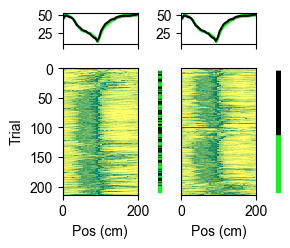

In [4]:
# --- Compute everything for both sort=False and sort=True ---
def get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort, trial_cat_priority=None):
    trial_numbers = np.array(beh['trial_number'])
    position = np.array(beh['P'])
    speed = np.array(beh['S'])
    stop_mask = speed < 3

    trial_numbers = trial_numbers[:len(stop_mask)]
    position = position[:len(stop_mask)]
    speed = speed[:len(stop_mask)]

    n_pos_bins = int(tl / 5)
    pos_bins = np.linspace(0, tl, n_pos_bins + 1)

    trial_df = beh['trials'][:int(last_ephys_bin/(tl/bs))]
    if sort:
        sorted_cats = trial_df.groupby(by=['context', 'type', 'performance'])
        if trial_cat_priority is not None:
            sorted_cats = sort_dict_by_priority(sorted_cats, trial_cat_priority)
        sorted_trial_indices = []
        for cat_indices in sorted_cats.values():
            sorted_trial_indices.extend(cat_indices.tolist())
        trial_order = sorted_trial_indices
    else:
        trial_order = trial_df.index.tolist()

    speed_matrix = np.full((len(trial_order), n_pos_bins), np.nan)
    trial_type_colors = []
    for i, ti in enumerate(trial_order):
        trial_num = trial_df['number'][ti]
        mask = (trial_numbers == trial_num)
        pos_trial = position[mask]
        speed_trial = speed[mask]
        bin_sums, _ = np.histogram(pos_trial, bins=pos_bins, weights=speed_trial)
        bin_counts, _ = np.histogram(pos_trial, bins=pos_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            speed_profile = bin_sums / bin_counts
        speed_matrix[i, :] = speed_profile

        trial_type = trial_df['type'][ti]
        if isinstance(trial_type, str):
            color = get_color_for_group(('rz1', trial_type, 'hit')) if 'get_color_for_group' in globals() else 'grey'
        else:
            color = 'grey'
        trial_type_colors.append(color)
    return speed_matrix, trial_type_colors, trial_order, pos_bins

def sem_nan(a, axis=0):
    # sample standard deviation (ddof=1) / sqrt(n) ignoring NaNs, returns NaN if n<=1
    n = np.sum(~np.isnan(a), axis=axis)
    std = np.nanstd(a, axis=axis, ddof=1)
    sem = np.where(n > 1, std / np.sqrt(n), np.nan)
    return sem

def trial_type_stats_from_speed_matrix(beh, last_ephys_bin, tl, bs, speed_matrix, trial_order):
    trial_df = beh['trials'][:int(last_ephys_bin/(tl/bs))]
    # trial_order contains indices into trial_df
    trial_types_order = [trial_df.loc[int(ti), 'type'] for ti in trial_order]

    pos_bins = np.linspace(0, tl, int(tl/5) + 1)
    pos_centers = (pos_bins[:-1] + pos_bins[1:]) / 2

    unique_types = [t for t in np.unique(np.array(trial_types_order)) if str(t) != 'nan']
    type_means = {}
    type_sems = {}
    for t in unique_types:
        rows = [i for i, tt in enumerate(trial_types_order) if tt == t]
        if len(rows) == 0:
            continue
        data = speed_matrix[rows, :]  # shape (n_trials_of_type, n_pos_bins)
        type_means[t] = np.nanmean(data, axis=0)
        type_sems[t] = sem_nan(data, axis=0)

    overall_mean = np.nanmean(speed_matrix, axis=0)
    overall_sem = sem_nan(speed_matrix, axis=0)

    return pos_centers, unique_types, type_means, type_sems, overall_mean, overall_sem



# --- Prepare data for both sort=False and sort=True ---
_, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day)

speed_matrix_unsorted, trial_type_colors_unsorted, trial_order_unsorted, pos_bins = get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=False)
speed_matrix_sorted, trial_type_colors_sorted, trial_order_sorted, _ = get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=True)

pos_centers_u, types_u, type_means_u, type_sems_u, overall_mean_u, overall_sem_u = trial_type_stats_from_speed_matrix(
    beh, last_ephys_bin, tl, bs, speed_matrix_unsorted, trial_order_unsorted
)

# --- Plot 4 columns: heatmap (unsorted), colors (unsorted), heatmap (sorted), colors (sorted) ---
fig, axes = plt.subplots(
    nrows=2, ncols=4, sharex='col', sharey=False,
    figsize=(rm_figsize[0]*3, rm_figsize[1]*1.7),
    gridspec_kw={'height_ratios': [0.25, 1], 'width_ratios': [20, 1, 20, 1]}
)

# 1st column: heatmap (unsorted)
ax = axes[1,0]
mesh = ax.pcolormesh(
    pos_bins, np.arange(len(trial_order_unsorted)+1),
    np.nan_to_num(speed_matrix_unsorted, nan=0),
    cmap='summer', shading='auto', vmin=0, vmax=60, 
    rasterized=True
)
ax.set_xlabel('Pos (cm)')
ax.set_ylabel('Trial')
ax.set_xlim(0, tl)
ax.set_ylim(0, len(trial_order_unsorted))
ax.invert_yaxis()
ax.axvspan(90, 110, alpha=0.2, zorder=-10, edgecolor='none', facecolor='grey')
yticks = np.arange(0.5, len(trial_order_unsorted)+0.5, 50)
ax.set_yticks(yticks)
ax.set_yticklabels([str(int(i)) for i in np.arange(0, len(trial_order_unsorted), 50)])

# 2nd column: trial colors (unsorted)
ax_color = axes[1,1]
for i, color in enumerate(trial_type_colors_unsorted):
    ax_color.scatter(0, i + 0.5, color=color, marker='s', s=20)
ax_color.set_xlim(-0.5, 0.5)
ax_color.set_xticks([])
ax_color.set_yticks([])
ax_color.set_frame_on(False)
ax_color.invert_yaxis()

# 3rd column: heatmap (sorted)
ax2 = axes[1,2]
mesh2 = ax2.pcolormesh(
    pos_bins, np.arange(len(trial_order_sorted)+1),
    np.nan_to_num(speed_matrix_sorted, nan=0),
    cmap='summer', shading='auto', vmin=0, vmax=60,
    rasterized=True
)
ax2.set_xlabel('Pos (cm)')
ax2.set_xlim(0, tl)
ax2.set_ylim(0, len(trial_order_sorted))
ax2.invert_yaxis()
ax2.axvspan(90, 110, alpha=0.2, zorder=-10, edgecolor='none', facecolor='grey')
ax2.set_yticks([])
ax2.set_yticklabels([])

# 4th column: trial colors (sorted)
ax_color2 = axes[1,3]
for i, color in enumerate(trial_type_colors_sorted):
    ax_color2.scatter(0, i + 0.5, color=color, marker='s', s=20)
ax_color2.set_xlim(-0.5, 0.5)
ax_color2.set_xticks([])
ax_color2.set_yticks([])
ax_color2.set_frame_on(False)

ax_avg = axes[0,0]
for t in types_u:
    ax_avg.plot(pos_centers_u, type_means_u[t], color=get_color_for_group(('rz1', t, 'hit')))
    ax_avg.fill_between(pos_centers_u, type_means_u[t] - type_sems_u[t], type_means_u[t] + type_sems_u[t], 
                        color=get_color_for_group(('rz1', t, 'hit')), alpha=0.25)


ax_avg = axes[0,2]
for t in types_u:
    ax_avg.plot(pos_centers_u, type_means_u[t], color=get_color_for_group(('rz1', t, 'hit')))
    ax_avg.fill_between(pos_centers_u, type_means_u[t] - type_sems_u[t], type_means_u[t] + type_sems_u[t], 
                        color=get_color_for_group(('rz1', t, 'hit')), alpha=0.25)

'''
# Add a single horizontal colorbar at the top, with ticks above
cbar_ax = fig.add_axes([0.25, 0.96, 0.5, 0.025])  # [left, bottom, width, height] in figure coordinates
cb = fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal')
cb.set_ticks([0, 60])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')
'''
axes[0,3].axis('off')
axes[0,1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_behaviour/behaviour_heatmaps_mouse{mouse}_day{day}.pdf', dpi=300)
plt.show()


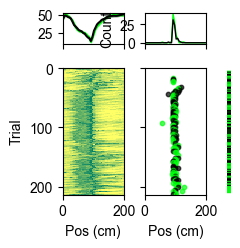

In [24]:
# --- Prepare data for both sort=False and sort=True ---
_, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day)

speed_matrix_unsorted, trial_type_colors_unsorted, trial_order_unsorted, pos_bins = get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=False)
speed_matrix_sorted, trial_type_colors_sorted, trial_order_sorted, _ = get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=True)

pos_centers_u, types_u, type_means_u, type_sems_u, overall_mean_u, overall_sem_u = trial_type_stats_from_speed_matrix(
    beh, last_ephys_bin, tl, bs, speed_matrix_unsorted, trial_order_unsorted
)

fig, axes = plt.subplots(
    nrows=2, ncols=3, sharex='col', sharey=False,
    figsize=(rm_figsize[0]*2.5, rm_figsize[1]*1.7),
    gridspec_kw={'height_ratios': [0.25, 1], 'width_ratios': [20, 20, 1]}
)

# 1st column: heatmap (unsorted)
ax = axes[1,0]
mesh = ax.pcolormesh(
    pos_bins, np.arange(len(trial_order_unsorted)+1),
    np.nan_to_num(speed_matrix_unsorted, nan=0),
    cmap='summer', shading='auto', vmin=0, vmax=60, 
    rasterized=True
)
ax.set_xlabel('Pos (cm)')
ax.set_ylabel('Trial')
ax.set_xlim(0, tl)
ax.set_ylim(0, len(trial_order_unsorted))
ax.invert_yaxis()
ax.axvspan(90, 110, alpha=0.2, zorder=-10, edgecolor='none', facecolor='grey')
yticks = np.arange(0.5, len(trial_order_unsorted)+0.5, 100)
ax.set_yticks(yticks)
ax.set_yticklabels([str(int(i)) for i in np.arange(0, len(trial_order_unsorted), 100)])

# 1st row, 2nd column: line histogram of stop locations by color
ax_hist = axes[0,1]
bin_edges = np.arange(0, 201, 5)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
color_to_stops = {}

for trial_idx in range(speed_matrix_unsorted.shape[0]):
    stops = np.where(speed_matrix_unsorted[trial_idx, :] < 3)[0]
    if len(stops) > 0:
        stop_pos = (pos_bins[:-1] + pos_bins[1:]) / 2
        color = trial_type_colors_unsorted[trial_idx]
        if color not in color_to_stops:
            color_to_stops[color] = []
        color_to_stops[color].extend(stop_pos[stops])

for color, stops in color_to_stops.items():
    hist, _ = np.histogram(stops, bins=bin_edges)
    ax_hist.plot(bin_centers, hist, color=color, label=str(color), linewidth=1)
ax_hist.set_xlim(0, 200)
ax_hist.set_ylabel('Count')

# 2nd column, second row: scatter plot of stop locations (speed < 3)
ax_stop = axes[1,1]
for trial_idx in range(speed_matrix_unsorted.shape[0]):
    stops = np.where(speed_matrix_unsorted[trial_idx, :] < 3)[0]
    if len(stops) > 0:
        stop_pos = (pos_bins[:-1] + pos_bins[1:]) / 2
        ax_stop.scatter(stop_pos[stops], [trial_idx+0.5]*len(stops), color=trial_type_colors_unsorted[trial_idx], s=10, alpha=0.7)
ax_stop.set_xlim(0, tl)
ax_stop.set_ylim(0, len(trial_order_unsorted))
ax_stop.invert_yaxis()
ax_stop.set_xlabel('Pos (cm)')
ax_stop.set_yticks(yticks)
ax_stop.set_yticklabels([])

# 2nd column: trial colors (unsorted)
ax_color = axes[1,2]
for i, color in enumerate(trial_type_colors_unsorted):
    ax_color.scatter(0, i + 0.5, color=color, marker='s', s=20)
ax_color.set_xlim(-0.5, 0.5)
ax_color.set_xticks([])
ax_color.set_yticks([])
ax_color.set_frame_on(False)
ax_color.invert_yaxis()

ax_avg = axes[0,0]
for t in types_u:
    ax_avg.plot(pos_centers_u, type_means_u[t], color=get_color_for_group(('rz1', t, 'hit')))
    ax_avg.fill_between(pos_centers_u, type_means_u[t] - type_sems_u[t], type_means_u[t] + type_sems_u[t], 
                        color=get_color_for_group(('rz1', t, 'hit')), alpha=0.25)

axes[0,2].axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_behaviour/behaviour_heatmaps_mouse{mouse}_day{day}.pdf', dpi=300)
plt.show()

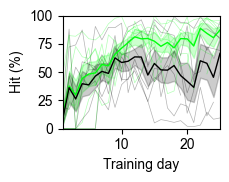

In [5]:
import matplotlib.pyplot as plt

# Ensure 'df_hits' exists and has the columns: mouse, day, percentage_hit_b, percentage_hit_nb

fig, ax = plt.subplots(figsize=(rm_figsize[0]*2.4, rm_figsize[1]*1.2))

# Plot each mouse's line (alpha=0.3)
for mouse, df_mouse in df_hits.groupby('mouse'):
    ax.plot(
        df_mouse['day'], df_mouse['percentage_hit_b'], linewidth=0.5,
        color='#00FF0D', alpha=0.3, label='Beaconed' if mouse == df_hits['mouse'].unique()[0] else ""
    )
    ax.plot(
        df_mouse['day'], df_mouse['percentage_hit_nb'], linewidth=0.5,
        color='black', alpha=0.3, label='Non-beaconed' if mouse == df_hits['mouse'].unique()[0] else ""
    )

# Calculate mean and SEM across mice for each day
days = np.sort(df_hits['day'].unique())
mean_b = df_hits.groupby('day')['percentage_hit_b'].mean()
sem_b = df_hits.groupby('day')['percentage_hit_b'].sem()
mean_nb = df_hits.groupby('day')['percentage_hit_nb'].mean()
sem_nb = df_hits.groupby('day')['percentage_hit_nb'].sem()

# Plot mean with SEM fill (alpha=1 for mean)
ax.plot(days, mean_b, color='#00FF0D', alpha=1, linewidth=1, label='Beaconed (mean)')
ax.fill_between(days, mean_b - sem_b, mean_b + sem_b, color='#00FF0D', alpha=0.2)

ax.plot(days, mean_nb, color='black', alpha=1, linewidth=1, label='Non-beaconed (mean)')
ax.fill_between(days, mean_nb - sem_nb, mean_nb + sem_nb, color='black', alpha=0.2)

ax.set_xlabel('Training day')
ax.set_ylabel('Hit (%)')
ax.set_ylim(0, 100)
ax.set_xlim(1,25)
ax.set_yticks([0,25,50,75,100])
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_behaviour/behaviour_hit_percentage.pdf', dpi=300)
plt.show()